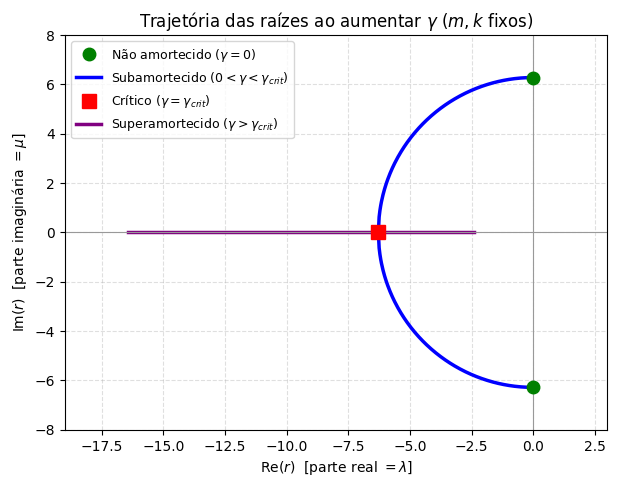

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m, k = 1.0, (2*np.pi)**2
w0 = np.sqrt(k/m)
gamma_crit = 2*np.sqrt(k*m)

fig, ax = plt.subplots(figsize=(7, 7))

# Não amortecido: gamma = 0 (raízes puramente imaginárias)
ax.plot([0, 0], [w0, -w0], 'o', color='green', markersize=9,
        label='Não amortecido ($\\gamma=0$)', zorder=5)

# Subamortecido: 0 < gamma < gamma_crit -> semicírculo de raio w0
gamma_sub = np.linspace(0, gamma_crit, 200)
re = -gamma_sub/(2*m)
im = np.sqrt(np.clip(k/m - (gamma_sub/(2*m))**2, 0, None))
ax.plot(re, im, color='blue', linewidth=2.5, label='Subamortecido ($0<\\gamma<\\gamma_{crit}$)')
ax.plot(re, -im, color='blue', linewidth=2.5)

# Crítico: gamma = gamma_crit (raiz dupla real, em -w0)
ax.plot(-gamma_crit/(2*m), 0, 's', color='red', markersize=10,
        label='Crítico ($\\gamma=\\gamma_{crit}$)', zorder=5)

# Superamortecido: gamma > gamma_crit -> duas raízes reais se afastando
gamma_sup = np.linspace(gamma_crit, 1.5*gamma_crit, 200)
disc = np.sqrt((gamma_sup/(2*m))**2 - k/m)
r1 = -gamma_sup/(2*m) + disc
r2 = -gamma_sup/(2*m) - disc
ax.plot(r1, np.zeros_like(r1), color='purple', linewidth=2.5, label='Superamortecido ($\\gamma>\\gamma_{crit}$)')
ax.plot(r2, np.zeros_like(r2), color='purple', linewidth=2.5)

ax.axhline(0, color='0.6', linewidth=0.8)
ax.axvline(0, color='0.6', linewidth=0.8)
ax.set_xlabel(r'Re($r$)  [parte real $=\lambda$]')
ax.set_ylabel(r'Im($r$)  [parte imaginária $=\mu$]')
ax.set_title(r'Trajetória das raízes ao aumentar $\gamma$ ($m,k$ fixos)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-19, 3)
ax.set_ylim(-8, 8)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

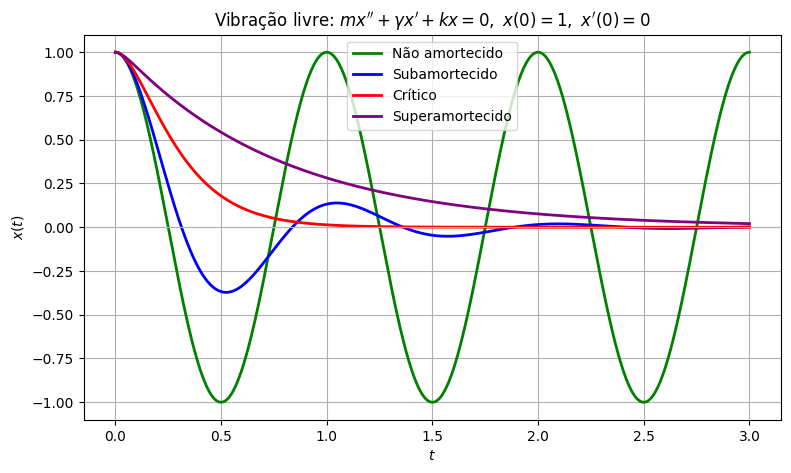

In [2]:
from scipy.integrate import odeint

def oscilador(estado, t, m, gamma, k):
    x, v = estado
    return [v, -(gamma/m)*v - (k/m)*x]

t = np.linspace(0, 3, 500)

casos = [
    ("Não amortecido", 0.0, 'g'),
    ("Subamortecido", 0.3*gamma_crit, 'b'),
    ("Crítico", gamma_crit, 'r'),
    ("Superamortecido", 2.5*gamma_crit, 'purple'),
]

plt.figure(figsize=(9, 5))
for label, gamma_, cor in casos:
    sol = odeint(oscilador, [1, 0], t, args=(m, gamma_, k))
    plt.plot(t, sol[:, 0], color=cor, linewidth=2, label=label)

plt.axhline(0, color='0.7', linewidth=0.8)
plt.title(r"Vibração livre: $mx''+\gamma x'+kx=0,\ x(0)=1,\ x'(0)=0$")
plt.xlabel("$t$"); plt.ylabel("$x(t)$")
plt.legend()
plt.grid(True)
plt.show()

R = 5,  delta = 0.9273 rad
Diferença (deve ser 0): 0


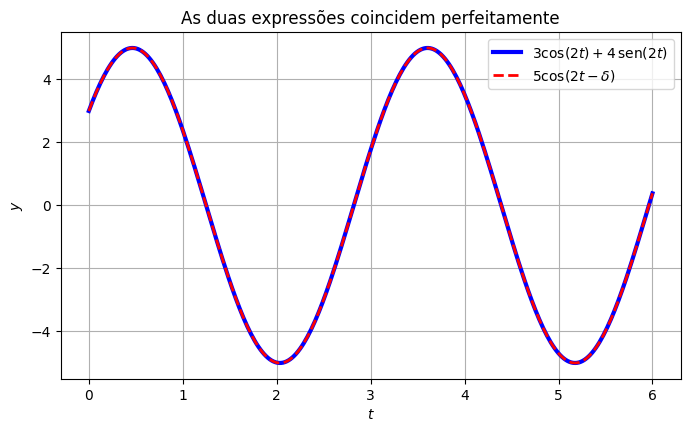

In [3]:
import sympy as sp

t_s, w_s = sp.symbols('t omega', real=True)
C1, C2 = 3, 4

R = sp.sqrt(C1**2 + C2**2)
delta = sp.atan2(C2, C1)

lado_esquerdo = C1*sp.cos(w_s*t_s) + C2*sp.sin(w_s*t_s)
lado_direito = R*sp.cos(w_s*t_s - delta)

print(f"R = {R},  delta = {float(delta):.4f} rad")
print("Diferença (deve ser 0):", sp.simplify(sp.expand_trig(lado_esquerdo - lado_direito)))

t_vals = np.linspace(0, 6, 300)
w_val = 2
le_vals = C1*np.cos(w_val*t_vals) + C2*np.sin(w_val*t_vals)
ld_vals = float(R)*np.cos(w_val*t_vals - float(delta))

plt.figure(figsize=(8, 4.5))
plt.plot(t_vals, le_vals, 'b', linewidth=3, label=r'$3\cos(2t)+4\,\mathrm{sen}(2t)$')
plt.plot(t_vals, ld_vals, 'r--', linewidth=2, label=r'$5\cos(2t-\delta)$')
plt.title("As duas expressões coincidem perfeitamente")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True)
plt.show()

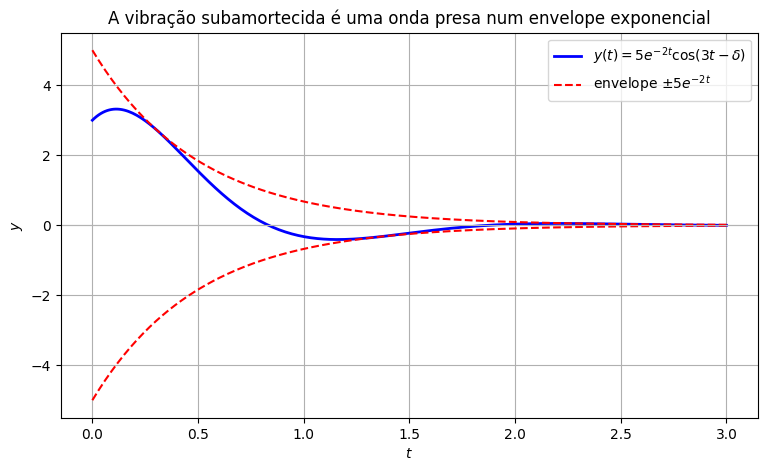

In [4]:
lam, mu = -2, 3
R_sub = 5
delta_sub = np.arctan2(4, 3)

t_vals = np.linspace(0, 3, 300)
y_vals = R_sub*np.exp(lam*t_vals)*np.cos(mu*t_vals - delta_sub)

plt.figure(figsize=(9, 5))
plt.plot(t_vals, y_vals, 'b', linewidth=2, label=r'$y(t)=5e^{-2t}\cos(3t-\delta)$')
plt.plot(t_vals, R_sub*np.exp(lam*t_vals), 'r--', linewidth=1.5, label=r'envelope $\pm5e^{-2t}$')
plt.plot(t_vals, -R_sub*np.exp(lam*t_vals), 'r--', linewidth=1.5)
plt.axhline(0, color='0.7', linewidth=0.8)
plt.title("A vibração subamortecida é uma onda presa num envelope exponencial")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True)
plt.show()